In [385]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [386]:
import pandas as pd

path = "/content/drive/MyDrive/Datasets/hatevsoffensive_language.csv"

df = pd.read_csv(path)

In [387]:
df.head()


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [388]:
!pip install contractions wordcloud gensim

In [389]:
import numpy as np
import re
import contractions
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.callbacks import EarlyStopping

from gensim.models import Word2Vec

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [390]:
df = df[['text', 'label']]

In [391]:
print(df['label'].unique())

['neither' 'offensive language' 'hate speec']


In [392]:
label_mapping = {
    'hate speec': 0,
    'offensive language': 1,
    'neither': 2
}

df['label'] = df['label'].map(label_mapping)

In [393]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [394]:
def clean_text(text):

    text = text.lower()

    text = contractions.fix(text)

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [395]:
df['cleaned_text'] = df['text'].apply(clean_text)

In [396]:
print(df[['text', 'cleaned_text']].head())

                                                text  \
0  !!! RT @mayasolovely: As a woman you shouldn't...   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...   
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...   
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...   

                                        cleaned_text  
0  rt woman complain cleaning house amp man alway...  
1  rt boy dat coldtyga dwn bad cuffin dat hoe st ...  
2  rt dawg rt ever fuck bitch start cry confused ...  
3                                rt look like tranny  
4  rt shit hear might true might faker bitch told ya  


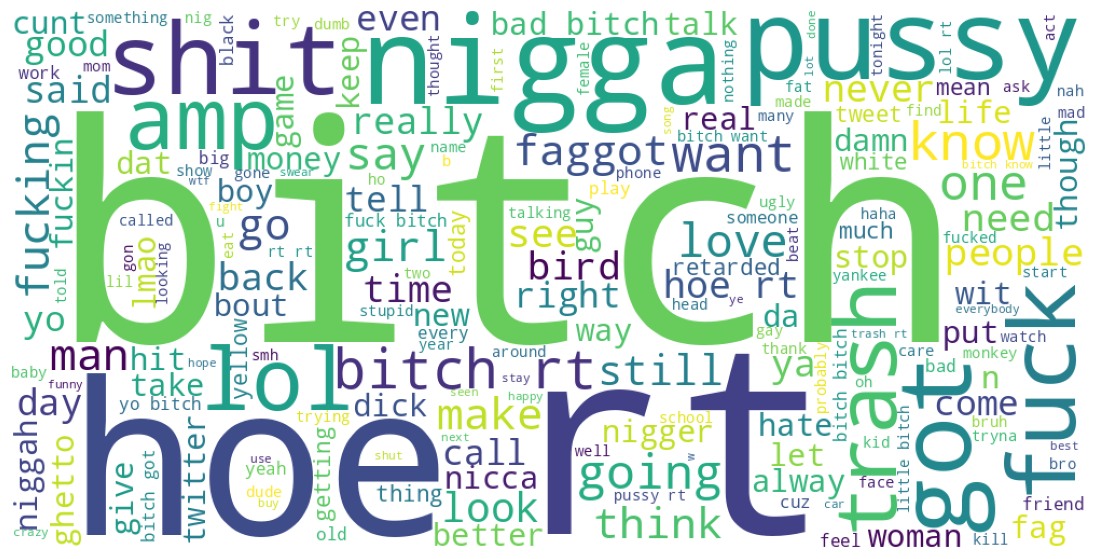

In [397]:
all_text = " ".join(df['cleaned_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [398]:
words = all_text.split()

common_words = Counter(words).most_common(20)

print(common_words)

[('bitch', 11305), ('rt', 7634), ('hoe', 4274), ('like', 2819), ('pussy', 2201), ('nigga', 1988), ('got', 1600), ('as', 1567), ('get', 1536), ('fuck', 1447), ('shit', 1279), ('trash', 1147), ('lol', 1063), ('want', 1001), ('know', 926), ('amp', 844), ('one', 750), ('love', 749), ('girl', 694), ('go', 692)]


In [399]:
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

In [400]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(5.797076023391813), np.int64(1): np.float64(0.4303077657681122), np.int64(2): np.float64(1.9857772435897436)}


In [401]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [402]:
sequence_lengths = [len(seq) for seq in X_train_seq]

max_len = int(np.percentile(sequence_lengths, 98))

print(max_len)

16


In [403]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post'
)

In [404]:
model1 = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=128,
    ),

    SimpleRNN(64),

    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [405]:
model2 = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=128,
    ),

    Bidirectional(LSTM(
        128,
        dropout=0.3,
        recurrent_dropout=0.3,
        return_sequences=True
    )),

    LSTM(64),

    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [406]:
sentences = [text.split() for text in X_train]
w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1
)

In [407]:
embedding_dim = 100

word_index = tokenizer.word_index

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim)
)

for word, i in word_index.items():

    if i < vocab_size:

        if word in w2v_model.wv:

            embedding_matrix[i] = w2v_model.wv[word]

In [408]:
model3 = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True
    ),

    Bidirectional(LSTM(
        128,
        return_sequences=True
    )),

    LSTM(64),

    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [409]:
model3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [410]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [411]:
history1 = model1.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step - accuracy: 0.7026 - loss: 0.8132 - val_accuracy: 0.8119 - val_loss: 0.6459
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.8226 - loss: 0.4645 - val_accuracy: 0.7874 - val_loss: 0.5631
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.8956 - loss: 0.2658 - val_accuracy: 0.8490 - val_loss: 0.4539
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.9335 - loss: 0.1579 - val_accuracy: 0.8308 - val_loss: 0.5681
Epoch 5/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.9531 - loss: 0.1224 - val_accuracy: 0.8122 - val_loss: 0.6030
Epoch 6/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.9594 - loss: 0.1059 - val_accuracy: 0.8439 - val_loss: 0.5529


In [412]:
history2 = model2.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 81s 144ms/step - accuracy: 0.8455 - loss: 0.4457 - val_accuracy: 0.8976 - val_loss: 0.3054
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 78s 135ms/step - accuracy: 0.9093 - loss: 0.2741 - val_accuracy: 0.9065 - val_loss: 0.2894
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 93s 158ms/step - accuracy: 0.9344 - loss: 0.2143 - val_accuracy: 0.8891 - val_loss: 0.3190
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 82s 166ms/step - accuracy: 0.9499 - loss: 0.1674 - val_accuracy: 0.8928 - val_loss: 0.3379
Epoch 5/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 84s 170ms/step - accuracy: 0.9624 - loss: 0.1222 - val_accuracy: 0.8820 - val_loss: 0.4076


In [413]:
history3 = model3.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 67s 120ms/step - accuracy: 0.8372 - loss: 0.4732 - val_accuracy: 0.9022 - val_loss: 0.3014
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 78s 113ms/step - accuracy: 0.9059 - loss: 0.2979 - val_accuracy: 0.9007 - val_loss: 0.3058
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 52s 105ms/step - accuracy: 0.9282 - loss: 0.2201 - val_accuracy: 0.8868 - val_loss: 0.3789


In [414]:
predictions = model2.predict(X_test_pad)

y_pred = np.argmax(predictions, axis=1)

155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step


In [415]:
print(accuracy_score(y_test, y_pred))

0.8898527335081703


In [416]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.33      0.01      0.02       290
           1       0.91      0.96      0.94      3832
           2       0.79      0.87      0.83       835

    accuracy                           0.89      4957
   macro avg       0.68      0.61      0.60      4957
weighted avg       0.86      0.89      0.86      4957



In [417]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[   3  249   38]
 [   3 3679  150]
 [   3  103  729]]


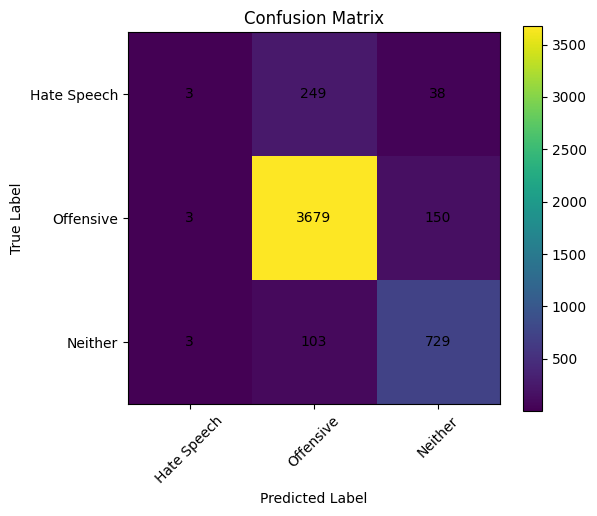

In [418]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

classes = ['Hate Speech', 'Offensive', 'Neither']

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(classes)):
    for j in range(len(classes)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.show()

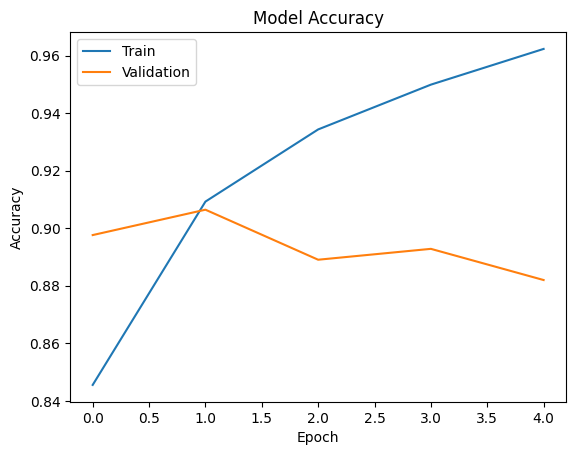

In [419]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

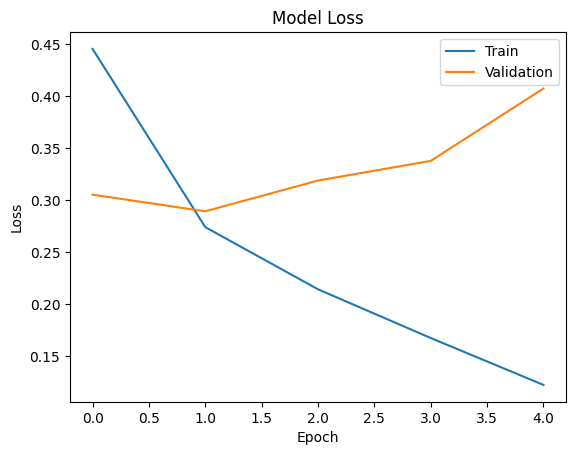

In [420]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [421]:
incorrect_indices = np.where(y_test.values != y_pred)[0]

print("Total Incorrect Predictions:", len(incorrect_indices))

Total Incorrect Predictions: 546


In [422]:
labels = {
    0: "Hate Speech",
    1: "Offensive Language",
    2: "Neither"
}

for i in incorrect_indices[:5]:

    print("TEXT:")
    print(X_test.iloc[i])

    print()

    print("ACTUAL:")
    print(labels[y_test.iloc[i]])

    print()

    print("PREDICTED:")
    print(labels[y_pred[i]])

    print()

    print("-" * 60)

TEXT:
rt lol credit near good know right man job ho nice though

ACTUAL:
Neither

PREDICTED:
Offensive Language

------------------------------------------------------------
TEXT:
search gay redneck episode play

ACTUAL:
Hate Speech

PREDICTED:
Offensive Language

------------------------------------------------------------
TEXT:
got love islamofascist cow try make retort age typical muzzie idiocy

ACTUAL:
Hate Speech

PREDICTED:
Neither

------------------------------------------------------------
TEXT:
say waste draft pick manziel mallet telling delete account retarded

ACTUAL:
Hate Speech

PREDICTED:
Neither

------------------------------------------------------------
TEXT:
rt aight game dyke ruin

ACTUAL:
Hate Speech

PREDICTED:
Offensive Language

------------------------------------------------------------


In [423]:
for i in range(10):

    print("TEXT:", X_test.iloc[i])
    print("ACTUAL:", y_test.iloc[i])
    print("PREDICTED:", y_pred[i])
    print()

TEXT: got missed call yo bitch
ACTUAL: 1
PREDICTED: 1

TEXT: rt fucking bad bitch gone need money lil homie
ACTUAL: 1
PREDICTED: 1

TEXT: rt lol credit near good know right man job ho nice though
ACTUAL: 2
PREDICTED: 1

TEXT: rt wipe cum faggot rt contact lens wildin cannot see shit
ACTUAL: 1
PREDICTED: 1

TEXT: nigga cheat bitch expect pay back whatsoever naive bitch
ACTUAL: 1
PREDICTED: 1

TEXT: mother asked wanted christmas year replied go crazy sister bitch
ACTUAL: 1
PREDICTED: 1

TEXT: real dedication bitch got diarrhea still shitting bathroom
ACTUAL: 1
PREDICTED: 1

TEXT: kiss going conductor courtesy bitch
ACTUAL: 1
PREDICTED: 1

TEXT: momma keep talking like bitch gtf twitter
ACTUAL: 1
PREDICTED: 1

TEXT: rt kno bitch thot want meet momma
ACTUAL: 1
PREDICTED: 1



In [424]:
predictions = model2.predict(X_test_pad)

y_pred = np.argmax(predictions, axis=1)

155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
